In [1]:
from dlfs.layers import EmbeddingLayer, PositionalEncoding, DenseLayer
from dlfs.modules import TransformerEncoder

from dlfs.activation import ReLU, Sigmoid
from dlfs.loss import BCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.base import Module, Activation, Loss, Optimizer
from dlfs.helpers import get_random_batch

import numpy as np

# Transformer Encoder only model

In [2]:
class TransformerEncoderModel(Module):

    def __init__(self, vocab_size: int, seq_len: int, 
                        n_embed: int = 512, n_head: int = 4, n_enc_layers: int = 2, dim_ff: int = 2048, 
                        dropout: float = 0.1, activation: Activation = ReLU, layer_norm_eps: float = 1e-5, 
                        loss_function: Loss = None, optimizer: Optimizer = None) -> None:
        """
        Encoder only Transformer model.

        Parameters
        ----------
        vocab_size : int
            The size of the vocabulary, i.e., the total number of unique tokens (words/characters) in the dataset.

        seq_len : int
            The maximum sequence length of the input/output sequences. The model will be trained on sequences of this length.

        n_embed : int, default=512
            The dimensionality of the embedding vectors for both input and output.

        n_head : int, default=4
            The number of attention heads in each attention layer.

        n_enc_layers : int, default=2
            The number of encoder layers.

        dim_ff : int, default=2048
            The dimensionality of the feedforward layers in the encoder and decoder.

        dropout : float, default=0.1
            The dropout rate applied to layers during training to help prevent overfitting.

        activation : Activation, default=ReLU()
            The activation function used in the feedforward layers.

        layer_norm_eps : float, default=1e-5
            A small value added to the denominator for numerical stability when performing layer normalization.

        loss_function : Loss, default=None
            The loss function used during training.

        optimizer : Optimizer, default=None
            The optimizer used for training.

        Returns
        -------
        None
        """
        
        self.loss_function = loss_function
        self.optimizer = optimizer

        self.embed_enc = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc_enc = PositionalEncoding(seq_len, n_embed)

        self.encoder = TransformerEncoder(d_model=n_embed, n_head=n_head, n_enc_layers=n_enc_layers,
                                          dim_ff=dim_ff, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps)

        self.linear = DenseLayer(n_embed, 1)
        self.sigm = Sigmoid()

    def forward(self, inputs_enc: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Transformer Encoder model. Creates output attribute of shape `(batch_size, 1)`.

        Parameters
        ----------
        inputs_enc : np.ndarray
            The input sequence for the encoder of shape `(batch_size, seq_len)`.

        training : bool, default=False
            A flag indicating whether the model is in training mode (`True`) or inference mode (`False`).
            This controls dropout, which is only applied during training.

        Returns
        -------
        None

        Notes
        -----
        - `inputs` are expected to be token indices for the encoder sequences.
        """

        self.embed_enc.forward(inputs_enc, training)

        self.pos_enc_enc.forward(self.embed_enc.output, training)

        self.encoder.forward(self.pos_enc_enc.output, training)

        pooled_output = np.mean(self.encoder.output, axis=1)  # Shape: (batch_size, d_model)

        self.linear.forward(pooled_output, training)

        self.sigm.forward(self.linear.output, training)

        self.output = self.sigm.output

    def backward(self, y: np.ndarray) -> None:
        """
        Backward pass for the Transformer Decoder model. Computes gradients for all Decoder modules.

        Parameters
        ----------
        y : np.ndarray
            The true labels (indices) for the model's output of shape `(batch_size, 1)`.

        Returns
        -------
        None
        """

        self.loss_function.backward(self.output, y)

        self.sigm.backward(self.loss_function.dinputs)

        self.linear.backward(self.sigm.dinputs)

        batch_size, seq_len, d_model = self.encoder.output.shape
        # Calculate the gradient w.r.t. the pooled output
        depooled_gradients = np.repeat(self.linear.dinputs, seq_len, axis=1) / seq_len  # Shape: (batch_size, seq_len, d_model)
        depooled_gradients = depooled_gradients.reshape(batch_size, seq_len, d_model)

        self.encoder.backward(depooled_gradients)

        self.pos_enc_enc.backward(self.encoder.dinputs)
        self.embed_enc.backward(self.pos_enc_enc.dinputs)

    def train(self, X: np.ndarray, y_true: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None) -> None:
        """
        Train the model for a specified number of epochs.


        Parameters
        ----------
        X : np.ndarray
            Decoder input data (shifted targets) of shape `(batch_size, seq_len)`.

        y : np.ndarray
            True target labels (indices) of shape `(batch_size, seq_len)`.

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        Returns
        -------
        None
        """

        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:

                batch_loss = 0

                for j in range(0, len(X), batch_size):

                    # Subset data into a batch
                    batch_X = X[j:j+batch_size, :]
                    batch_y = y_true[j:j+batch_size]

                    # Forward pass
                    self.forward(batch_X, training=True)

                    batch_loss += self.loss_function.calculate(self.output, batch_y)

                    # Backward pass
                    self.backward(batch_y)

                    self.optimizer.pre_update_parameters()
                    self.optimizer.update_parameters(self)
                    self.optimizer.post_update_parameters()

                self.loss_vals.append(batch_loss / (len(X) // batch_size))

                if print_every is not None and not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS : {batch_loss / (len(X) // batch_size)} =====')

            else:
                self.forward(X, training=True)
                self.backward(y_true)

                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                loss = self.loss_function.calculate(self.output, y_true)
                self.loss_vals.append(loss)

                if print_every is not None and not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')
                
    def predict(self, X: np.ndarray) -> np.ndarray:
        self.forward(X)
        return self.output > 0.5

# Dummy dataset, helper functions

In [3]:
def generate_encoder_dataset(num_samples: int, seq_length: int, vocab_size: int):
    """
    Generate a dataset for classification based on sum of sequence.
    - If the sum of the sequence is even, label is 0.
    - If the sum of the sequence is odd, label is 1.
    """
    # Generate random sequences of integers
    X = np.random.randint(1, vocab_size, size=(num_samples, seq_length))
    
    # Compute the sum of each sequence
    sequence_sums = np.sum(X, axis=1)
    
    # Generate binary labels: 0 if sum is even, 1 if sum is odd
    y = sequence_sums % 2
    
    return X, y

# Creating dataset, preprocessing

In [4]:
num_samples = 100
seq_len = 5
vocab_size = 20

X_train, y_train = generate_encoder_dataset(num_samples, seq_len, vocab_size)
y_train = y_train.reshape(-1, 1) # adjusting shape for BCE loss fn
              
print('-----------------------------------------------------')
print(f'Data shapes:\nX: {X_train.shape} || y: {y_train.shape}')
print('-----------------------------------------------------')
print(f'Example input sequence for encoder: {X_train[0]}')
print(f'Example target: {y_train[0]}')
print('-----------------------------------------------------')

-----------------------------------------------------
Data shapes:
X: (100, 5) || y: (100, 1)
-----------------------------------------------------
Example input sequence for encoder: [13  2  6 19 13]
Example target: [1]
-----------------------------------------------------


# Model training

In [5]:
#np.random.seed(1)

batch_size = None

n_embed = 64
n_head = 8
n_enc_layers = 1
dim_ff = 128
dropout = 0.
eps = 1e-5

epochs = 500
lr = 1e-4

loss = BCE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr, decay=0., clip_grad=False)

model = TransformerEncoderModel(vocab_size=vocab_size, 
                         seq_len=seq_len, 
                         n_embed=n_embed, 
                         n_head=n_head,
                         n_enc_layers=n_enc_layers,
                         dim_ff=dim_ff, 
                         dropout=dropout,
                         layer_norm_eps=eps,
                         loss_function=loss, 
                         optimizer=optimizer)

model.train(X_train, y_train, print_every=100, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 1.6000223042146957 =====
===== EPOCH : 100 ===== LOSS : 0.6860313479874766 =====
===== EPOCH : 200 ===== LOSS : 0.6630187577080442 =====
===== EPOCH : 300 ===== LOSS : 0.5929098627721596 =====
===== EPOCH : 400 ===== LOSS : 0.37441150083917324 =====
===== EPOCH : 500 ===== LOSS : 0.1218532242810457 =====


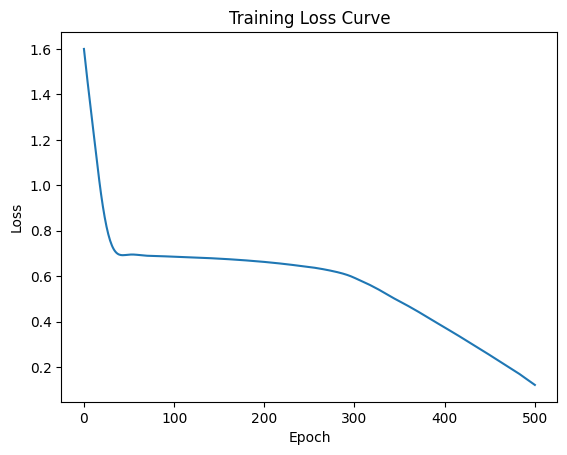

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_vals)), model.loss_vals)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Inference on train data

In [7]:
model.forward(X_train, training=False)
result = (model.output > 0.5).astype(int)

print(result[:10].reshape(-1))
print(y_train[:10].reshape(-1))
print(f'Accuracy: {np.mean(y_train == result)}')

[1 1 1 1 0 0 1 0 1 1]
[1 1 1 1 0 0 1 0 1 1]
Accuracy: 0.98


# Inference on test data

In [25]:
X_test, y_test = generate_encoder_dataset(num_samples=10, seq_length=seq_len, vocab_size=vocab_size)
model.forward(X_test, training=False)
result = (model.output > 0.5).astype(int)

print(result[:5].reshape(-1))
print(y_train[:5].reshape(-1))
print(f'Accuracy: {np.mean(y_test == result)}')

[1 1 1 1 1]
[1 1 1 1 0]
Accuracy: 0.54
